# NF1 3D pilot cropped voxel view

View real 3D single-cell crops (with mask overlays) from two NF1 wells in one `CytoDataFrame`.

Most of the setup below isn't about `CytoDataFrame` -- it's working around this
data's layout, which doesn't look like typical CellProfiler output:

- There are no `Image_FileName_*`/`Image_PathName_*` columns, so each row's raw
  image path is built from the patient/well/field metadata (`image_path`).
- Every well's mask file has the exact same generic name (`nuclei_mask.tiff`),
  so combining two wells into one table needs `stage_mask` to tell them apart
  -- a single-well notebook wouldn't need this at all.

The actual `CytoDataFrame(...)` call at the end is just a handful of arguments.

In [1]:
import os
import pathlib
import re
import tempfile

import pandas as pd

from cytodataframe import CytoDataFrame

# Local mount point for bandicoot. Set BANDICOOT_LOCAL_BASE if it is mounted
# somewhere else on your machine.
BANDICOOT_LOCAL_BASE = pathlib.Path(
    os.environ.get("BANDICOOT_LOCAL_BASE", "~/mnt/bandicoot")
).expanduser()
DATA_DIR = BANDICOOT_LOCAL_BASE / "NF1_organoid_data/data"
PROFILES_DIR = (
    DATA_DIR / "image_based_profiles_production_zedprofiler/ibp/sc_profiles_related"
)
assert PROFILES_DIR.is_dir(), (
    f"Profiles not found at {PROFILES_DIR}. Set the BANDICOOT_LOCAL_BASE "
    "environment variable to wherever bandicoot is mounted on this machine."
)

# An "image set" here is one well + field-of-view (one 3D image). Add every
# image set you want to view to this list -- e.g. all wells/fields in a
# plate for per-plate QC -- not just the two shown here.
IMAGE_SETS = [
    "NF0055_T1__NF0055_T1__B10__F1",
    "NF0014_T1__NF0014_T1__C4__F2",
]
CHANNEL = "DNA"
CHANNEL_CODE = "405"
COMPARTMENT = "Nuclei"

# Scratch dir for the mask symlinks `stage_mask` creates below (see its
# comment) -- not part of the repo, just local working space.
MASK_LINK_DIR = pathlib.Path(tempfile.gettempdir()) / "cytodataframe_nf1_3d_mask_links"
MASK_LINK_DIR.mkdir(exist_ok=True)


def image_path(row: pd.Series, kind: str, filename: str) -> pathlib.Path:
    # e.g. data/NF0055_T1/zstack_images/B10-1/B10-1_405.tif
    well_field = (
        f"{row['Metadata_Experiment_WellID']}-{row['Metadata_Imaging_FieldID']}"
    )
    return (
        DATA_DIR
        / row["Metadata_Biology_PatientTumor"]
        / kind
        / well_field
        / filename.format(well_field=well_field)
    )


def load_image_set(image_set: str) -> tuple[pd.DataFrame, pathlib.Path, pathlib.Path]:
    profiles = pd.read_parquet(PROFILES_DIR / f"{image_set}.parquet").head(1)
    row = profiles.iloc[0]
    channel_path = image_path(
        row, "zstack_images", "{well_field}_" + CHANNEL_CODE + ".tif"
    )
    mask_path = image_path(
        row, "segmentation_masks", COMPARTMENT.lower() + "_mask.tiff"
    )
    profiles[f"Image_FileName_{CHANNEL}"] = str(channel_path)
    return profiles, channel_path, mask_path


def stage_mask(channel_path: pathlib.Path, mask_path: pathlib.Path) -> pathlib.Path:
    # Every well's mask has the same generic filename (e.g. "nuclei_mask.tiff"),
    # so symlink under a name that embeds the raw stem to tell rows apart.
    link = MASK_LINK_DIR / f"{channel_path.stem}__{mask_path.name}"
    if not link.exists():
        link.symlink_to(mask_path)
    return link

Load one object per well into a single two-row table.

In [2]:
profile_rows = []
for image_set in IMAGE_SETS:
    profiles, channel_path, mask_path = load_image_set(image_set)
    stage_mask(channel_path, mask_path)
    profile_rows.append(profiles)

profiles = pd.concat(profile_rows, ignore_index=True)
mask_name = mask_path.name

GridspecLayout(children=(HTML(value="<div style='width:100%;height:100%;background:#EBEBEB;padding:5px 4px 5px…

,Image_FileName_DNA
0,
1,

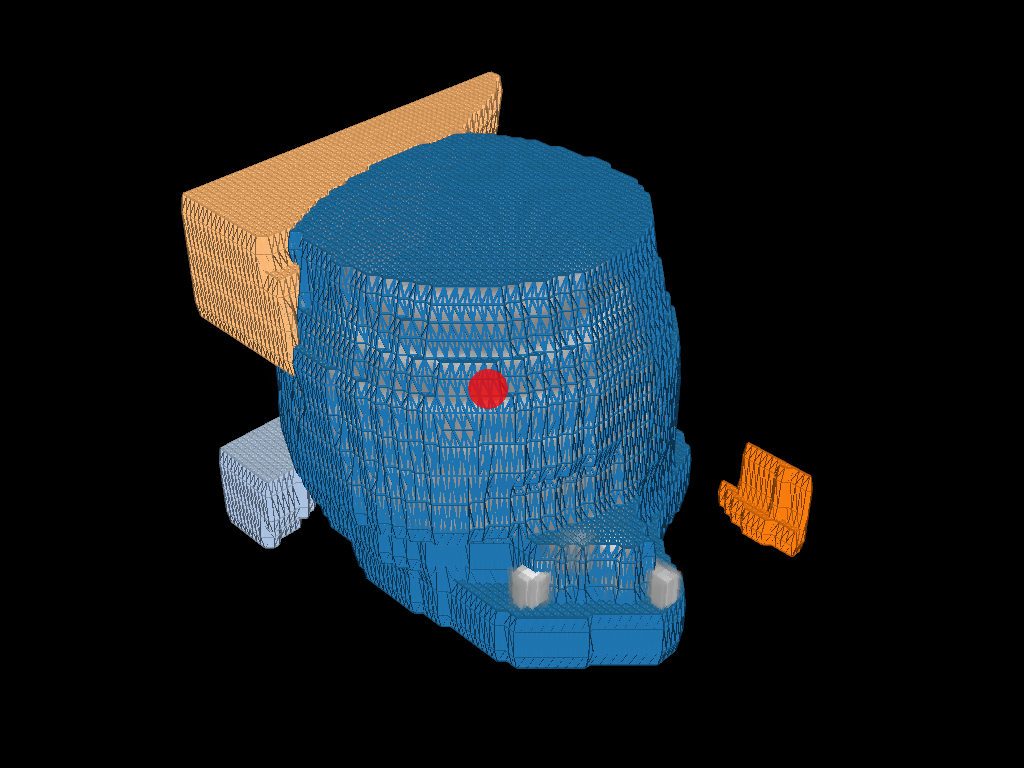
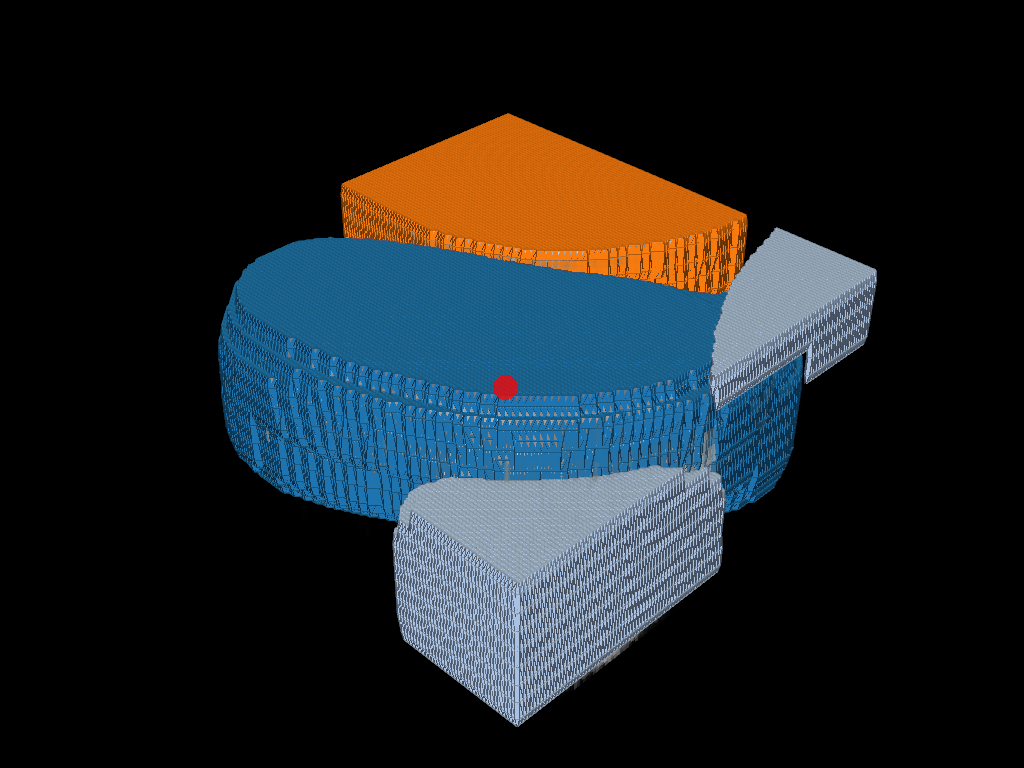

In [3]:
bbox_column_map = {
    "x_min": f"{COMPARTMENT}_NoChannel_VolumeSizeShape_MinX",
    "x_max": f"{COMPARTMENT}_NoChannel_VolumeSizeShape_MaxX",
    "y_min": f"{COMPARTMENT}_NoChannel_VolumeSizeShape_MinY",
    "y_max": f"{COMPARTMENT}_NoChannel_VolumeSizeShape_MaxY",
    "z_min": f"{COMPARTMENT}_NoChannel_VolumeSizeShape_MinZ",
    "z_max": f"{COMPARTMENT}_NoChannel_VolumeSizeShape_MaxZ",
}

center_columns = [
    f"{COMPARTMENT}_NoChannel_VolumeSizeShape_Center{axis}" for axis in "XYZ"
]

voxel_view = CytoDataFrame(
    data=profiles[[f"Image_FileName_{CHANNEL}"]],
    data_bounding_box=profiles[list(bbox_column_map.values())],
    compartment_center_xy=profiles[center_columns],
    data_mask_context_dir=str(MASK_LINK_DIR),
    segmentation_file_regex={rf"__{re.escape(mask_name)}$": r"_\d+\.tif$"},
    display_options={
        "width": 260,
        "height": 260,
        "table_max_height": "580px",
        "label_overlay_mode": "filled",
        # Voxel size (x, y, z) in um. These TIFFs carry no voxel-size
        # metadata, and z is coarser than xy, so without this the objects are
        # drawn too flat. xy_spacing (0.1) is the NF1 3D pipeline manifests'
        # recorded value; z_spacing (0.5) was chosen visually against these
        # two objects rather than read from the manifests (which record 1.0).
        "volume_spacing": (0.1, 0.1, 0.5),
        "volume_bbox_column_map": bbox_column_map,
    },
)
# The rendered widget includes a "Mask" checkbox to toggle the overlay on/off,
# and a red dot marking each object's center.
voxel_view